Device: cuda
Scanning dataset folders...
  train  →  site: 769  no_site: 1764  total: 2533
  validation  →  site: 177  no_site: 407  total: 584
  test  →  site: 150  no_site: 350  total: 500

  Training (LiDAR Only) | Epochs 30 | Comparing TRAIN vs TEST
Ep 01/30 | LR: 9.97e-05  ✓ saved
  Train -> Loss: 0.0701 | AUC: 0.6571 | F1: 0.6690
  Test  -> Loss: 0.0690 | AUC: 0.6861 | F1: 0.4862
Ep 02/30 | LR: 9.89e-05  ✓ saved
  Train -> Loss: 0.0611 | AUC: 0.7555 | F1: 0.7227
  Test  -> Loss: 0.0699 | AUC: 0.7046 | F1: 0.4859
Ep 03/30 | LR: 9.76e-05  ✓ saved
  Train -> Loss: 0.0588 | AUC: 0.7883 | F1: 0.7314
  Test  -> Loss: 0.0669 | AUC: 0.7277 | F1: 0.4916
Ep 04/30 | LR: 9.57e-05
  Train -> Loss: 0.0552 | AUC: 0.8225 | F1: 0.7301
  Test  -> Loss: 0.0683 | AUC: 0.7198 | F1: 0.5313
Ep 05/30 | LR: 9.34e-05
  Train -> Loss: 0.0526 | AUC: 0.8436 | F1: 0.7539
  Test  -> Loss: 0.0668 | AUC: 0.7270 | F1: 0.5237
Ep 06/30 | LR: 9.05e-05  ✓ saved
  Train -> Loss: 0.0516 | AUC: 0.8464 | F1: 0.7576
  Tes

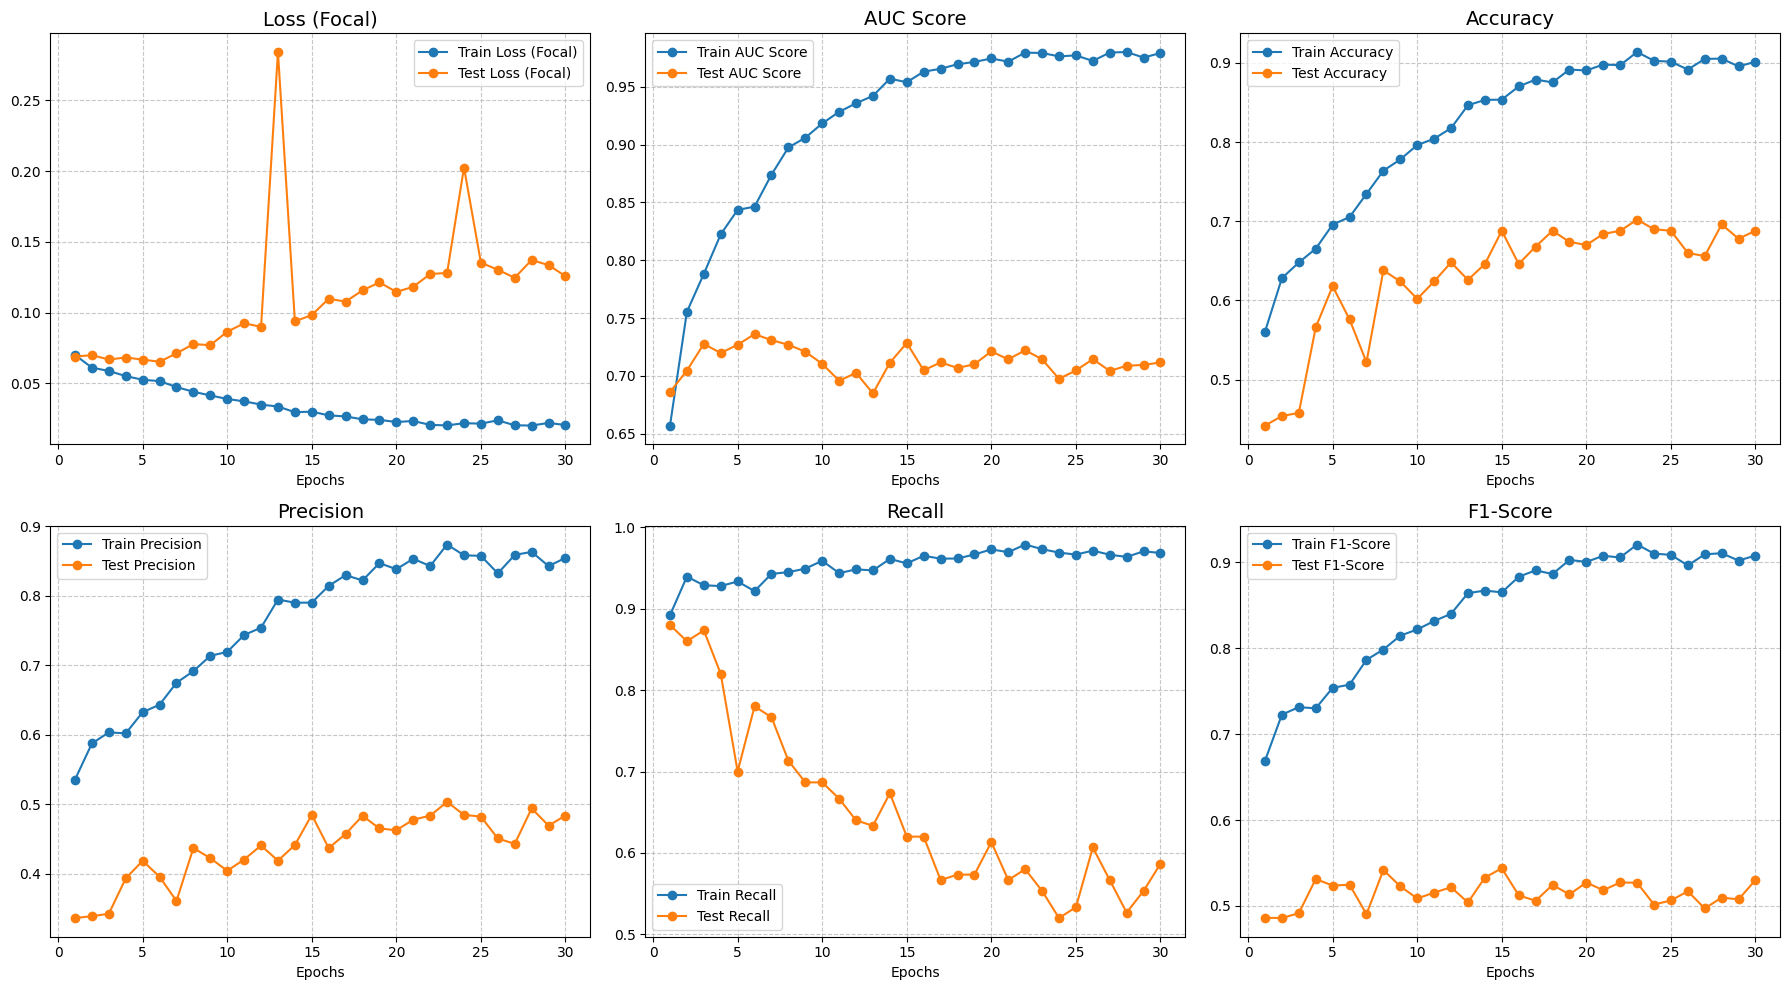

In [5]:
# !pip install -q rasterio  # uncomment if needed
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, precision_recall_curve

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/2nd-variation/FINALCNNDATA_NEW_01')
    
    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'
    
    OUTPUT_DIR    = Path('/kaggle/working')

    IMG_SUFFIX    = '.tif'
    # ONLY keeping LiDAR indices: HS0, HS1, HS2, HS3, LRM, slope, SVF
    LIDAR_BANDS   = [4, 5, 6, 7, 8, 9, 10]   

    NUM_LIDAR_CH      = 7
    NUM_CLASSES       = 1
    PRETRAINED        = True
    FREEZE_BACKBONES  = True  
    DROPOUT           = 0.5   

    IMG_SIZE     = 250
    BATCH_SIZE   = 16
    NUM_EPOCHS   = 30
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    SEED         = 42
    NUM_WORKERS  = 2
    USE_AMP      = False

    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTION FOR CLASS IMBALANCE
# ══════════════════════════════════════════════════════════════════════════════
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')
 
    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-bce_loss)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# ══════════════════════════════════════════════════════════════════════════════
# BUILD DATAFRAMES FROM FOLDER STRUCTURE
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        if not files:
            print(f"⚠️ WARNING: No files found in {folder}!")
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    
    df = pd.DataFrame(rows, columns=['filepath', 'label'])
    
    if len(df) > 0:
        print(f"  {site_dir.parent.name}  →  site: {(df['label']==1).sum()}  "
              f"no_site: {(df['label']==0).sum()}  total: {len(df)}")
    return df

print('Scanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE,  CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,    CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,   CFG.TEST_NOSITE)

if len(train_df) == 0:
    raise FileNotFoundError("Training DataFrame is empty. Check CFG.ROOT path!")

# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
def load_patch(path: str) -> np.ndarray:
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == '.npy':
        arr = np.load(path)
    elif suffix == '.npz':
        arr = np.load(path)['data']
    elif suffix in ('.tif', '.tiff'):
        import rasterio
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)
    else:
        raise ValueError(f'Unsupported format: {suffix}')
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    elif arr.ndim == 3 and arr.shape[-1] < arr.shape[0]:
        arr = arr.transpose(2, 0, 1)
    return arr.astype(np.float32)

def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        ch = arr[c]
        out[c] = (ch - ch.mean()) / (ch.std() + 1e-6)
    return out

class ArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        
    def __len__(self): return len(self.df)
    
    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)
        return t
        
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t    = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t    = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                         interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        if self.is_train:
            t = self._augment(t)
        
        return t[CFG.LIDAR_BANDS], torch.tensor(row['label'], dtype=torch.float32)

class ArchSiteTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t    = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t    = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                         interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        return t[CFG.LIDAR_BANDS], Path(row['filepath']).name

# ══════════════════════════════════════════════════════════════════════════════
# SINGLE-STREAM MODEL (LiDAR ONLY)
# ══════════════════════════════════════════════════════════════════════════════
class LiDAREfficientNet(nn.Module):
    def __init__(self, in_channels: int = 7, num_classes: int = 1,
                 pretrained: bool = True, freeze_backbones: bool = True,
                 dropout: float = 0.5, unfreeze_last_n_blocks: int = 3):
        super().__init__()
        weights  = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights)
 
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None,
        )
        if pretrained:
            with torch.no_grad():
                mean_w = old_conv.weight.mean(dim=1, keepdim=True)
                new_conv.weight.copy_(mean_w.repeat(1, in_channels, 1, 1))
 
        self.backbone.features[0][0] = new_conv
 
        if freeze_backbones:
            for param in self.backbone.features.parameters():
                param.requires_grad = False
            for param in self.backbone.features[0][0].parameters():
                param.requires_grad = True
            total_blocks = len(self.backbone.features)
            for block in self.backbone.features[total_blocks - unfreeze_last_n_blocks:]:
                for param in block.parameters():
                    param.requires_grad = True
 
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )
 
    def forward(self, x):
        return self.backbone(x)

def get_model():
    return LiDAREfficientNet(
        in_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        pretrained=CFG.PRETRAINED,
        freeze_backbones=CFG.FREEZE_BACKBONES,
        dropout=CFG.DROPOUT,
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, all_labels, all_preds = 0.0, [], []
    for lidar, labels in loader:
        lidar   = lidar.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            logits = model(lidar).squeeze(1)
            loss   = criterion(logits, labels)
            
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)
    
    return total_loss / len(loader.dataset), auc, prec, rec, f1, acc

@torch.no_grad()
def valid_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    for lidar, labels in loader:
        lidar   = lidar.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)
        
        with autocast(enabled=CFG.USE_AMP):
            logits = model(lidar).squeeze(1)
            loss   = criterion(logits, labels)
            
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)
    
    return total_loss / len(loader.dataset), auc, prec, rec, f1, acc


# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

trn_loader = DataLoader(ArchSiteDataset(train_df, is_train=True),
                        batch_size=CFG.BATCH_SIZE, sampler=sampler, 
                        num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

# LOAD TEST DATA FOR EVALUATION LOOP
test_loader = DataLoader(ArchSiteDataset(test_df, is_train=False),
                        batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN
# ══════════════════════════════════════════════════════════════════════════════
model     = get_model()
criterion = BinaryFocalLoss() 
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)
best_auc  = 0.0
ckpt_path = CFG.OUTPUT_DIR / 'efficientnet_b0_lidar_best.pth'

print(f'\n{"="*65}')
print(f'  Training (LiDAR Only) | Epochs {CFG.NUM_EPOCHS} | Comparing TRAIN vs TEST')
print(f'{"="*65}')

history = {
    'train_loss': [], 'train_auc': [], 'train_prec': [], 'train_rec': [], 'train_f1': [], 'train_acc': [],
    'test_loss': [], 'test_auc': [], 'test_prec': [], 'test_rec': [], 'test_f1': [], 'test_acc': []
}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    # Train
    trn_loss, trn_auc, trn_prec, trn_rec, trn_f1, trn_acc = train_epoch(model, trn_loader, criterion, optimizer, scaler)
    # Compare against TEST instead of Validation
    tst_loss, tst_auc, tst_prec, tst_rec, tst_f1, tst_acc = valid_epoch(model, test_loader, criterion)
    
    scheduler.step()
    
    history['train_loss'].append(trn_loss); history['test_loss'].append(tst_loss)
    history['train_auc'].append(trn_auc);   history['test_auc'].append(tst_auc)
    history['train_prec'].append(trn_prec); history['test_prec'].append(tst_prec)
    history['train_rec'].append(trn_rec);   history['test_rec'].append(tst_rec)
    history['train_f1'].append(trn_f1);     history['test_f1'].append(tst_f1)
    history['train_acc'].append(trn_acc);   history['test_acc'].append(tst_acc)
    
    saved = ''
    if tst_auc > best_auc:
        best_auc = tst_auc
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
        
    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved}')
    print(f'  Train -> Loss: {trn_loss:.4f} | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f}')
    print(f'  Test  -> Loss: {tst_loss:.4f} | AUC: {tst_auc:.4f} | F1: {tst_f1:.4f}')


# ══════════════════════════════════════════════════════════════════════════════
# PLOT FINAL TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def plot_full_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metrics = [
        ('loss', 'Loss (Focal)'), ('auc', 'AUC Score'), ('acc', 'Accuracy'),
        ('prec', 'Precision'), ('rec', 'Recall'), ('f1', 'F1-Score')
    ]
    
    for i, (key, title) in enumerate(metrics):
        ax = axes[i]
        ax.plot(epochs, history[f'train_{key}'], label=f'Train {title}', marker='o')
        ax.plot(epochs, history[f'test_{key}'], label=f'Test {title}', marker='o')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()

plot_full_history(history)